# Original Split Sequence-Level Analysis

In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

In [ ]:
# ── SET YOUR PATH HERE ───────────────────────────────
BASE = Path("C:/Users/rabia/Documents/Thesis/original_split")
# ─────────────────────────────────────────────────────
DATA_DIR_token = BASE / "token_level"
DATA_DIR_sequence = BASE / "sequence_level"
OUT_DIR = BASE / "sanity_checks" / "token_sanity_results"
FIG_DIR = BASE / "sanity_checks" / "token_sanity_results" / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_LABELS = {
    "llava": "LLaVA-OV-7B",
    "qwen3b": "Qwen2.5-VL-3B",
    "qwen7b": "Qwen2.5-VL-7B",
}

MODEL_ORDER_DEFAULT = ["LLaVA-OV-7B", "Qwen2.5-VL-3B", "Qwen2.5-VL-7B"]

MODEL_COLORS = {
    "LLaVA-OV-7B": "#B8CBAA",
    "Qwen2.5-VL-3B": "#AFC4E8",
    "Qwen2.5-VL-7B": "#D69C6D",
}

DOMAIN_ORDER = ["Animals", "Chess Pieces", "Flags", "Game Boards", "Logos"]

OUTPUT_PATTERN = "*_original_model_outputs.csv"
SIGNAL_PATTERN = "*_original_numeric_signal.csv"

if "DOMAIN_ORDER" not in globals():
    DOMAIN_ORDER = ["Animals", "Chess Pieces", "Flags", "Game Boards", "Logos"]

if "REPORT_COLORS" not in globals():
    REPORT_COLORS = {
        "bg": "#FFFFFF",
        "panel": "#FFFFFF",
        "text": "#111111",
        "muted": "#666666",
        "grid": "#D9D9D9",
        "darkgrey": "#444444",
        "blue": "#AFC4E8",
        "green": "#B8CBAA",
        "orange": "#D69C6D",
        "red": "#C76F5B",
        "brown": "#8B6F5A",
        "grey": "#EAEAEA",
    }

plt.rcParams.update({
    "figure.facecolor": REPORT_COLORS["bg"],
    "axes.facecolor": REPORT_COLORS["panel"],
    "axes.edgecolor": REPORT_COLORS["grid"],
    "axes.labelcolor": REPORT_COLORS["text"],
    "xtick.color": REPORT_COLORS["muted"],
    "ytick.color": REPORT_COLORS["muted"],
    "text.color": REPORT_COLORS["text"],
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})


In [4]:
def infer_model_key_from_sequence_file(path: Path) -> str:
    return path.name.split("_original_sequence_")[0].lower()


def infer_model_label_from_sequence_file(path: Path) -> str:
    key = infer_model_key_from_sequence_file(path)
    return MODEL_LABELS.get(key, key)


def get_model_order_from_df(df: pd.DataFrame):
    present = list(pd.Series(df["model"].dropna().unique()))
    return [m for m in MODEL_ORDER_DEFAULT if m in present] + sorted(
        [m for m in present if m not in MODEL_ORDER_DEFAULT]
    )


def find_sequence_files(pattern: str):
    """
    Search in a few likely locations so the cell works both in Colab folders
    and when files are uploaded directly into the runtime.
    """
    search_dirs = [
        DATA_DIR_sequence
    ]

    paths = []
    for d in search_dirs:
        if d.exists():
            paths.extend(sorted(d.glob(pattern)))

    # remove duplicates while preserving order
    unique_paths = []
    seen = set()
    for p in paths:
        key = str(p.resolve())
        if key not in seen:
            seen.add(key)
            unique_paths.append(p)

    return unique_paths


def load_and_stack_sequence(pattern: str, file_type: str) -> pd.DataFrame:
    paths = find_sequence_files(pattern)

    if not paths:
        raise FileNotFoundError(
            f"No sequence {file_type} files found for pattern {pattern!r}. "
            f"Checked: {DATA_DIR_sequence}, current directory, and /mnt/data."
        )

    parts = []
    for path in paths:
        df = pd.read_csv(path)
        df["model"] = infer_model_label_from_sequence_file(path)
        df["model_key"] = infer_model_key_from_sequence_file(path)
        df["source_file"] = path.name
        parts.append(df)
        print(f"Loaded {file_type:>10}: {path.name:<55} {df.shape}")

    return pd.concat(parts, ignore_index=True, sort=False)


def save_fig_once(name: str):
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print("Saved:", path)


def clean_axes_safe(ax, grid_axis="x"):
    if grid_axis in {"x", "y", "both"}:
        ax.grid(axis=grid_axis, color=REPORT_COLORS["grid"], linewidth=0.85, alpha=0.85)

    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(REPORT_COLORS["grid"])
    ax.spines["bottom"].set_color(REPORT_COLORS["grid"])
    ax.tick_params(axis="x", colors=REPORT_COLORS["muted"])
    ax.tick_params(axis="y", colors=REPORT_COLORS["text"])


def ordered_values_safe(values, preferred_order):
    values = list(pd.Series(values).dropna().unique())
    return [x for x in preferred_order if x in values] + sorted(
        [x for x in values if x not in preferred_order]
    )


In [5]:
sequence_results_raw = load_and_stack_sequence(
    "*_original_sequence_results*.csv",
    "results",
)

sequence_candidates_raw = load_and_stack_sequence(
    "*_original_sequence_candidates.csv",
    "candidates",
)

Loaded    results: llava_original_sequence_results_with_pmi.csv            (163, 86)
Loaded    results: qwen3b_original_sequence_results.csv                    (163, 74)
Loaded    results: qwen7b_original_sequence_results_with_pmi.csv           (163, 74)
Loaded candidates: llava_original_sequence_candidates.csv                  (814, 32)
Loaded candidates: qwen3b_original_sequence_candidates.csv                 (814, 20)
Loaded candidates: qwen7b_original_sequence_candidates.csv                 (814, 20)


In [ ]:
OUT_DIR = BASE / "sanity_checks" / "seq_sanity_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
SEQUENCE_MODEL_ORDER = get_model_order_from_df(sequence_results_raw)

raw_sequence_results_path = OUT_DIR / "original_sequence_results_all_models_raw_stacked.csv"
raw_sequence_candidates_path = OUT_DIR / "original_sequence_candidates_all_models_raw_stacked.csv"

sequence_results_raw.to_csv(raw_sequence_results_path, index=False)
sequence_candidates_raw.to_csv(raw_sequence_candidates_path, index=False)

print("\nSaved raw stacked sequence files:")
print(raw_sequence_results_path)
print(raw_sequence_candidates_path)

print("\nShapes:")
print("sequence_results_raw:", sequence_results_raw.shape)
print("sequence_candidates_raw:", sequence_candidates_raw.shape)


Saved raw stacked sequence files:
C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\outputs_sequence\original_sequence_results_all_models_raw_stacked.csv
C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\outputs_sequence\original_sequence_candidates_all_models_raw_stacked.csv

Shapes:
sequence_results_raw: (489, 86)
sequence_candidates_raw: (2442, 32)


In [8]:
def safe_numeric(df: pd.DataFrame, col: str, default=np.nan):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series(default, index=df.index)


def safe_bool(df: pd.DataFrame, col: str, default=False):
    if col in df.columns:
        return df[col].fillna(default).astype(bool)
    return pd.Series(default, index=df.index)


def first_available_col(df: pd.DataFrame, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def prepare_sequence_results(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    required = ["model", "ID", "topic", "ground_truth_num"]
    missing = [c for c in required if c not in out.columns]
    if missing:
        raise KeyError(f"Missing required sequence result columns: {missing}")

    out["gt_num_eval"] = safe_numeric(out, "ground_truth_num")
    out["pred_num_eval"] = safe_numeric(out, "pred_num")
    out["proxy_num_eval"] = safe_numeric(out, "proxy_bias_value")

    # Core margins
    out["avg_margin"] = safe_numeric(out, "avg_margin")
    out["seq_margin"] = safe_numeric(out, "seq_margin")
    out["char_margin"] = safe_numeric(out, "char_margin")

    # Main preference variable
    if "prefers_gt_seq" in out.columns:
        out["prefers_gt_seq"] = safe_bool(out, "prefers_gt_seq")
    elif "prefers_gold" in out.columns:
        out["prefers_gt_seq"] = safe_bool(out, "prefers_gold")
    else:
        out["prefers_gt_seq"] = out["avg_margin"] > 0

    out["correct_numeric_eval"] = safe_bool(out, "correct_numeric")
    out["generated_matches_proxy"] = safe_bool(out, "generated_matches_proxy")

    # Robust generated outcome categories
    out["generated_matches_proxy"] = (
        out["generated_matches_proxy"]
        | (
            out["pred_num_eval"].notna()
            & out["proxy_num_eval"].notna()
            & out["pred_num_eval"].eq(out["proxy_num_eval"])
            & ~out["correct_numeric_eval"]
        )
    )

    conditions = [
        out["correct_numeric_eval"],
        out["generated_matches_proxy"],
        out["pred_num_eval"].notna(),
    ]

    choices = [
        "correct",
        "proxy_confusion",
        "other_numeric_error",
    ]

    out["sequence_outcome"] = np.select(
        conditions,
        choices,
        default="non_numeric_or_missing",
    )

    # Rank and entropy
    out["gt_rank_seq"] = safe_numeric(out, "gt_rank_seq")
    out["entropy_step1"] = safe_numeric(out, "entropy_step1")
    out["entropy_mean"] = safe_numeric(out, "entropy_mean")
    out["entropy_candidates"] = safe_numeric(out, "entropy_candidates")

    # Candidate/token length diagnostics
    out["gold_n_tokens"] = safe_numeric(out, "gold_n_tokens")
    out["bias_n_tokens"] = safe_numeric(out, "bias_n_tokens")
    out["same_length"] = safe_bool(out, "same_length", default=np.nan)

    # PMI fields if present
    out["pmi_margin"] = safe_numeric(out, "pmi_margin")
    out["prefers_gt_pmi"] = np.where(
        out["pmi_margin"].notna(),
        out["pmi_margin"] > 0,
        np.nan,
    )

    out["pmi_available"] = out["pmi_margin"].notna()

    out["pmi_agrees_with_avg"] = np.where(
        out["pmi_available"] & out["avg_margin"].notna(),
        np.sign(out["pmi_margin"]) == np.sign(out["avg_margin"]),
        np.nan,
    )

    # Margin strength bins for interpretation
    out["margin_strength"] = pd.cut(
        out["avg_margin"],
        bins=[-np.inf, -2, 0, 2, np.inf],
        labels=[
            "strong proxy preference",
            "weak proxy preference",
            "weak GT preference",
            "strong GT preference",
        ],
    )

    return out


def prepare_sequence_candidates(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    required = ["model", "ID", "topic", "candidate", "avg_logprob"]
    missing = [c for c in required if c not in out.columns]
    if missing:
        raise KeyError(f"Missing required sequence candidate columns: {missing}")

    out["candidate_num_eval"] = safe_numeric(out, "candidate")
    out["gt_num_eval"] = safe_numeric(out, "ground_truth_num")
    out["avg_logprob"] = safe_numeric(out, "avg_logprob")
    out["seq_logprob"] = safe_numeric(out, "seq_logprob")
    out["char_logprob"] = safe_numeric(out, "char_logprob")
    out["n_tokens"] = safe_numeric(out, "n_tokens")
    out["entropy_step1"] = safe_numeric(out, "entropy_step1")
    out["entropy_mean"] = safe_numeric(out, "entropy_mean")
    out["is_gt_candidate"] = out["candidate_num_eval"].eq(out["gt_num_eval"])

    if "status" in out.columns:
        out["candidate_ok"] = out["status"].eq("ok")
    else:
        out["candidate_ok"] = out["avg_logprob"].notna()

    return out

In [9]:
sequence_results = prepare_sequence_results(sequence_results_raw)
sequence_candidates = prepare_sequence_candidates(sequence_candidates_raw)

processed_sequence_results_path = OUT_DIR / "original_sequence_results_all_models_processed.csv"
sequence_results.to_csv(processed_sequence_results_path, index=False)

print("Saved processed sequence file:")
print(processed_sequence_results_path)

Saved processed sequence file:
C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\outputs_sequence\original_sequence_results_all_models_processed.csv


In [12]:
sequence_results

,idx,ID,image_path,topic,sub_topic,question_type,type_of_question,prompt,prompt_used_for_generation,ground_truth,ground_truth_raw,ground_truth_num,model_answer,pred_norm,gt_norm,pred_num,correct_exact,correct_numeric,generation_error,run_mode,fallback_used,original_error_before_fallback,image_resize_applied,max_image_side,original_image_width,original_image_height,processed_image_width,processed_image_height,input_ids_shape,pixel_values_shape,num_image_crops,expected_bias,proxy_bias_value,proxy_bias_definition,candidate_policy,candidate_set,num_candidates_attempted,num_candidates_scored,answer_step,detected_digit,detected_token_text,gold_seq_logprob,gold_avg_logprob,gold_char_logprob,gold_entropy_step1,gold_entropy_mean,gold_n_tokens,gold_span_mode,bias_seq_logprob,bias_avg_logprob,bias_char_logprob,bias_entropy_step1,bias_entropy_mean,bias_n_tokens,bias_span_mode,seq_margin,avg_margin,char_margin,gt_rank_seq,prefers_gold,prefers_gt_seq,entropy_candidates,entropy_step1,entropy_mean,generated_matches_proxy,full_hallucination,same_length,length_matched,relative_change,gt_minus_bias,direction,gold_uncond_avg_lp,bias_uncond_avg_lp,gold_uncond_char_lp,bias_uncond_char_lp,gold_pmi,bias_pmi,pmi_margin,prefers_gold_pmi,gold_char_pmi,bias_char_pmi,char_pmi_margin,prefers_gold_char_pmi,model,model_key,source_file,gt_num_eval,pred_num_eval,proxy_num_eval,correct_numeric_eval,sequence_outcome,prefers_gt_pmi,pmi_available,pmi_agrees_with_avg,margin_strength
0,0,flag_of_australia_prompt1,original_images/images/Flag of Australia.png,Flags,flags,Counting/Illusion,Counting/Illusion,"How many stars are there in this flag? Answer with a number in curly brackets, e.g., {9}.","How many stars are there in this flag? Answer with a number in curly brackets, e.g., {9}.\nAnswer with exactly one i...",6,6,6,7,7,6,7.0,False,False,NaN,original,False,NaN,False,NaN,768.0,512.0,768.0,512.0,"(1, 2749)","(1, 5, 3, 384, 384)",5.0,7,7,best non-GT candidate from GT±2 by avg_logprob,GT±2,"[4, 5, 6, 7, 8]",5,5,0.0,7.0,7.0,-4.011913,-4.011913,-4.011913,0.711818,0.711818,1,exact,-2.340039,-2.340039,-2.340039,0.711818,0.711818,1,exact,-1.671875,-1.671875,-1.671875,3,False,False,1.102378,1.481871,1.481871,True,False,True,True,0.142857,-1.0,GT<proxy,-8.309811,-8.745602,-8.309811,-8.745602,4.297897,6.405563,-2.107666,False,4.297897,6.405563,-2.107666,False,LLaVA-OV-7B,llava,llava_original_sequence_results_with_pmi.csv,6,7.0,7,False,proxy_confusion,0.0,True,1.0,weak proxy preference
1,2,flag_of_burundi_prompt1,original_images/images/Flag of Burundi.png,Flags,flags,Counting/Illusion,Counting/Illusion,"How many stars are there in this flag? Answer with a number in curly brackets, e.g., {9}.","How many stars are there in this flag? Answer with a number in curly brackets, e.g., {9}.\nAnswer with exactly one i...",3,3,3,3,3,3,3.0,True,True,NaN,original,False,NaN,False,NaN,768.0,512.0,768.0,512.0,"(1, 2749)","(1, 5, 3, 384, 384)",5.0,4,4,best non-GT candidate from GT±2 by avg_logprob,GT±2,"[1, 2, 3, 4, 5]",5,5,0.0,3.0,3.0,-2.459261,-2.459261,-2.459261,0.445573,0.445573,1,exact,-4.396761,-4.396761,-4.396761,0.445573,0.445573,1,exact,1.937500,1.937500,1.937500,1,True,True,0.581114,1.068313,1.068313,False,False,True,True,0.250000,-1.0,GT<proxy,-7.756099,-7.884029,-7.756099,-7.884029,5.296838,3.487268,1.809570,True,5.296838,3.487268,1.809570,True,LLaVA-OV-7B,llava,llava_original_sequence_results_with_pmi.csv,3,3.0,4,True,correct,1.0,True,1.0,weak GT preference
2,4,flag_of_cape_verde_prompt1,original_images/images/Flag of Cape Verde.png,Flags,flags,Counting/Illusion,Counting/Illusion,"How many stars are there in this flag? Answer with a number in curly brackets, e.g., {9}.","How many stars are there in this flag? Answer with a number in curly brackets, e.g., {9}.\nAnswer with exactly one i...",10,10,10,8,8,10,8.0,False,False,NaN,original,False,NaN,False,NaN,768.0,512.0,768.0,512.0,"(1, 2749)","(1, 5, 3, 384, 384)",5.0,8,8,best non-GT candidate from GT±2 by avg_logprob,GT±2,"[8, 9, 1

In [10]:
sequence_summary = (
    sequence_results
    .groupby("model", as_index=False)
    .agg(
        n=("avg_margin", "size"),
        prefers_gt_seq_pct=("prefers_gt_seq", lambda x: 100 * x.mean()),
        numeric_accuracy_pct=("correct_numeric_eval", lambda x: 100 * x.mean()),
        proxy_confusion_pct=("generated_matches_proxy", lambda x: 100 * x.mean()),
        mean_avg_margin=("avg_margin", "mean"),
        median_avg_margin=("avg_margin", "median"),
        mean_entropy_step1=("entropy_step1", "mean"),
        mean_entropy_candidates=("entropy_candidates", "mean"),
        pmi_available_pct=("pmi_available", lambda x: 100 * x.mean()),
        pmi_agreement_pct=("pmi_agrees_with_avg", lambda x: 100 * x.dropna().mean() if x.notna().any() else np.nan),
        prefers_gt_pmi_pct=("prefers_gt_pmi", lambda x: 100 * pd.Series(x).dropna().mean() if pd.Series(x).notna().any() else np.nan),
    )
)

sequence_topic_summary = (
    sequence_results
    .groupby(["model", "topic"], as_index=False)
    .agg(
        n=("avg_margin", "size"),
        prefers_gt_seq_pct=("prefers_gt_seq", lambda x: 100 * x.mean()),
        numeric_accuracy_pct=("correct_numeric_eval", lambda x: 100 * x.mean()),
        proxy_confusion_pct=("generated_matches_proxy", lambda x: 100 * x.mean()),
        mean_avg_margin=("avg_margin", "mean"),
        median_avg_margin=("avg_margin", "median"),
        mean_entropy_step1=("entropy_step1", "mean"),
        pmi_agreement_pct=("pmi_agrees_with_avg", lambda x: 100 * x.dropna().mean() if x.notna().any() else np.nan),
    )
)

candidate_summary = (
    sequence_candidates
    .groupby("model", as_index=False)
    .agg(
        n_candidate_rows=("candidate", "size"),
        n_samples=("ID", "nunique"),
        mean_candidates_per_sample=("candidate", lambda x: len(x) / sequence_candidates.loc[x.index, "ID"].nunique()),
        candidate_ok_pct=("candidate_ok", lambda x: 100 * x.mean()),
        mean_candidate_tokens=("n_tokens", "mean"),
        multi_token_candidate_pct=("n_tokens", lambda x: 100 * (x > 1).mean()),
    )
)

In [11]:
print("Sequence summary by model:")
display(sequence_summary.round(3))

print("Sequence summary by model and topic:")
display(sequence_topic_summary.round(3))

print("Candidate-set summary:")
display(candidate_summary.round(3))

Sequence summary by model:


,model,n,prefers_gt_seq_pct,numeric_accuracy_pct,proxy_confusion_pct,mean_avg_margin,median_avg_margin,mean_entropy_step1,mean_entropy_candidates,pmi_available_pct,pmi_agreement_pct,prefers_gt_pmi_pct
0,LLaVA-OV-7B,163,84.663,80.982,14.110,3.763,5.281,0.521,0.369,100.000,94.479,82.209
1,Qwen2.5-VL-3B,163,72.393,80.368,12.883,2.376,2.719,0.489,0.551,99.387,88.889,79.012
2,Qwen2.5-VL-7B,163,90.184,85.276,7.975,5.046,7.188,0.168,0.261,100.000,97.546,90.184


Sequence summary by model and topic:


,model,topic,n,prefers_gt_seq_pct,numeric_accuracy_pct,proxy_confusion_pct,mean_avg_margin,median_avg_margin,mean_entropy_step1,pmi_agreement_pct
0,LLaVA-OV-7B,Animals,91,100.000,100.000,0.000,5.882,5.938,0.061,100.000
1,LLaVA-OV-7B,Chess Pieces,2,100.000,50.000,0.000,0.387,0.387,1.346,100.000
2,LLaVA-OV-7B,Flags,19,47.368,36.842,36.842,-0.220,-0.148,1.253,78.947
3,LLaVA-OV-7B,Game Boards,4,75.000,50.000,0.000,1.004,1.037,0.935,100.000
4,LLaVA-OV-7B,Logos,47,70.213,65.957,34.043,1.650,1.078,1.044,89.362
5,Qwen2.5-VL-3B,Animals,91,97.802,100.000,0.000,4.650,5.109,0.040,100.000
6,Qwen2.5-VL-3B,Chess Pieces,2,100.000,0.000,0.000,0.852,0.852,1.233,100.000
7,Qwen2.5-VL-3B,Flags,19,52.632,57.895,21.053,-0.498,0.359,1.016,84.211
8,Qwen2.5-VL-3B,Game Boards,4,50.000,50.000,0.000,-0.018,-0.002,1.047,50.000
9,Qwen2.5-VL-3B,Logos,47,31.915,57.447,36.170,-0.661,-0.453,1.078,71.739


Candidate-set summary:


,model,n_candidate_rows,n_samples,mean_candidates_per_sample,candidate_ok_pct,mean_candidate_tokens,multi_token_candidate_pct
0,LLaVA-OV-7B,814,121,6.727,100.0,1.06,6.02
1,Qwen2.5-VL-3B,814,121,6.727,100.0,1.06,6.02
2,Qwen2.5-VL-7B,814,121,6.727,100.0,1.06,6.02


Saved: C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\figures\original_sequence_model_dashboard.png


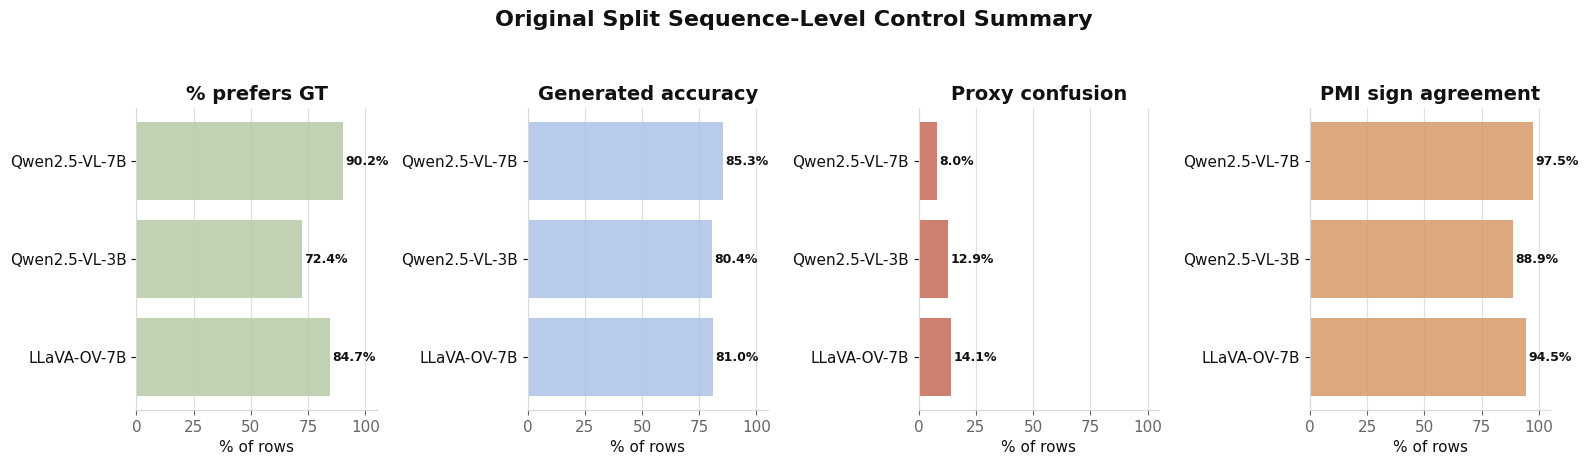

In [12]:
def plot_sequence_model_dashboard():
    df = sequence_summary.copy()
    df["model"] = pd.Categorical(df["model"], categories=SEQUENCE_MODEL_ORDER, ordered=True)
    df = df.sort_values("model")

    metrics = [
        ("prefers_gt_seq_pct", "% prefers GT", REPORT_COLORS["green"]),
        ("numeric_accuracy_pct", "Generated accuracy", REPORT_COLORS["blue"]),
        ("proxy_confusion_pct", "Proxy confusion", REPORT_COLORS["red"]),
        ("pmi_agreement_pct", "PMI sign agreement", REPORT_COLORS["orange"]),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4.4), facecolor="white")

    for ax, (col, title, color) in zip(axes, metrics):
        values = df[col]

        bars = ax.barh(
            df["model"],
            values,
            color=color,
            alpha=0.88,
        )

        for bar, val in zip(bars, values):
            if pd.isna(val):
                continue

            ax.text(
                val + 1.0,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%",
                va="center",
                ha="left",
                fontsize=9,
                fontweight="bold",
            )

        ax.set_title(title)
        ax.set_xlim(0, 105)
        ax.set_xlabel("% of rows")
        clean_axes_safe(ax, grid_axis="x")

    fig.suptitle(
        "Original Split Sequence-Level Control Summary",
        fontsize=16,
        fontweight="bold",
        y=1.05,
    )

    plt.tight_layout()
    save_fig_once("original_sequence_model_dashboard")
    plt.show()


plot_sequence_model_dashboard()

Saved: C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\figures\original_sequence_domain_margin_heatmap.png


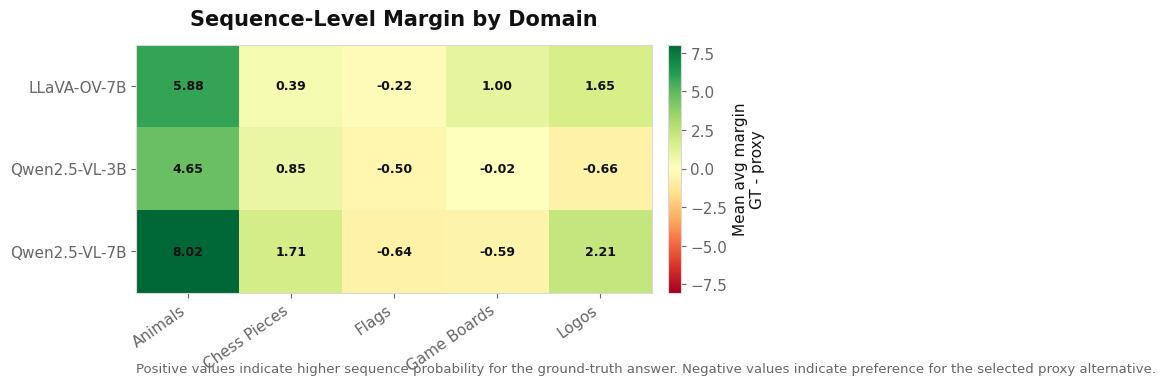

In [13]:
def plot_sequence_margin_heatmap():
    df = sequence_topic_summary.copy()

    topics = ordered_values_safe(df["topic"], DOMAIN_ORDER)
    models = [m for m in SEQUENCE_MODEL_ORDER if m in df["model"].unique()]

    heat = (
        df.pivot(index="model", columns="topic", values="mean_avg_margin")
        .reindex(index=models, columns=topics)
    )

    if heat.empty:
        print("No data for heatmap.")
        return

    vmax = np.nanmax(np.abs(heat.values))
    vmax = max(vmax, 1)

    fig, ax = plt.subplots(figsize=(1.35 * len(topics) + 3, 4.2), facecolor="white")

    im = ax.imshow(
        heat.values,
        cmap="RdYlGn",
        vmin=-vmax,
        vmax=vmax,
        aspect="auto",
    )

    ax.set_xticks(np.arange(len(topics)))
    ax.set_xticklabels(topics, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(models)))
    ax.set_yticklabels(models)

    for i in range(len(models)):
        for j in range(len(topics)):
            val = heat.values[i, j]
            if pd.isna(val):
                label = ""
            else:
                label = f"{val:.2f}"

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="#111111",
            )

    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label("Mean avg margin\nGT - proxy")

    ax.set_title(
        "Sequence-Level Margin by Domain",
        fontsize=15,
        fontweight="bold",
        pad=14,
    )

    ax.text(
        0,
        -0.28,
        "Positive values indicate higher sequence probability for the ground-truth answer. "
        "Negative values indicate preference for the selected proxy alternative.",
        transform=ax.transAxes,
        fontsize=9.5,
        color=REPORT_COLORS["muted"],
        ha="left",
        va="top",
    )

    plt.tight_layout()
    save_fig_once("original_sequence_domain_margin_heatmap")
    plt.show()


plot_sequence_margin_heatmap()

Saved: C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\figures\original_sequence_margin_strength_distribution.png


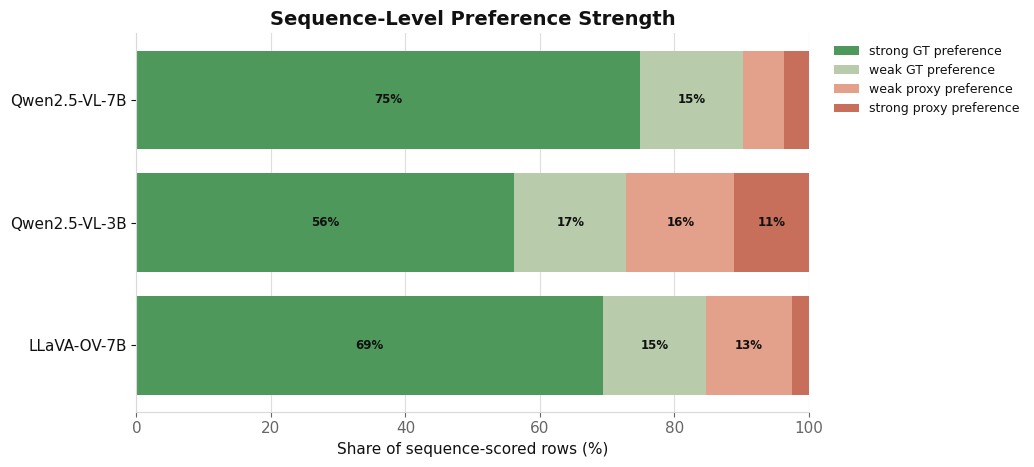

In [14]:
def plot_sequence_margin_strength():
    strength_order = [
        "strong GT preference",
        "weak GT preference",
        "weak proxy preference",
        "strong proxy preference",
    ]

    strength_colors = {
        "strong GT preference": "#4F985B",
        "weak GT preference": "#B8CBAA",
        "weak proxy preference": "#E3A08A",
        "strong proxy preference": "#C76F5B",
    }

    df = sequence_results.copy()
    df["margin_strength"] = pd.Categorical(
        df["margin_strength"],
        categories=strength_order,
        ordered=True,
    )

    counts = (
        df.groupby(["model", "margin_strength"], observed=False)
        .size()
        .reset_index(name="n")
    )

    counts["pct"] = (
        100 * counts["n"] / counts.groupby("model")["n"].transform("sum")
    )

    pivot = (
        counts.pivot(index="model", columns="margin_strength", values="pct")
        .reindex(index=SEQUENCE_MODEL_ORDER)
        .reindex(columns=strength_order)
        .fillna(0)
    )

    fig, ax = plt.subplots(figsize=(10.5, 4.8), facecolor="white")

    left = np.zeros(len(pivot))

    for strength in strength_order:
        vals = pivot[strength].values

        ax.barh(
            pivot.index,
            vals,
            left=left,
            color=strength_colors[strength],
            label=strength,
        )

        for yi, start, val in zip(range(len(pivot)), left, vals):
            if val >= 7:
                ax.text(
                    start + val / 2,
                    yi,
                    f"{val:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8.5,
                    fontweight="bold",
                )

        left += vals

    ax.set_title("Sequence-Level Preference Strength")
    ax.set_xlabel("Share of sequence-scored rows (%)")
    ax.set_xlim(0, 100)
    ax.legend(
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
    )
    clean_axes_safe(ax, grid_axis="x")

    plt.tight_layout()
    save_fig_once("original_sequence_margin_strength_distribution")
    plt.show()


plot_sequence_margin_strength()

C:\Users\rabia\AppData\Local\Temp\ipykernel_13616\3580496232.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="lower right")


Saved: C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\figures\original_sequence_candidate_window_example.png


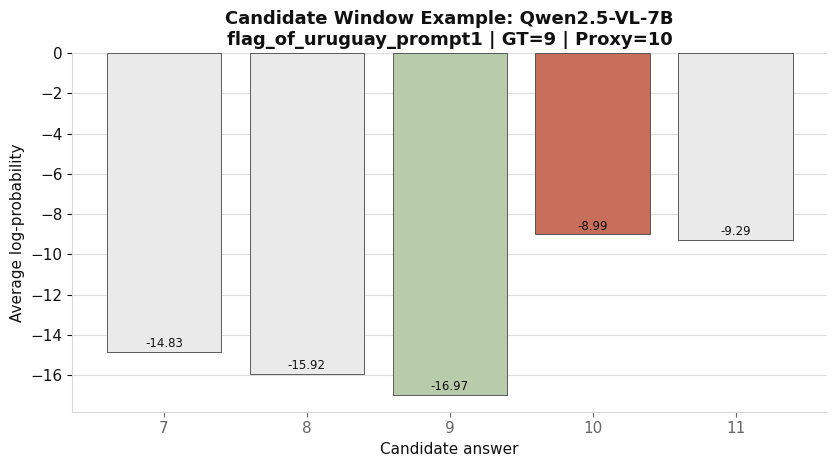

In [15]:
def select_interesting_sequence_example():
    """
    Pick a readable example where GT does not win, if available.
    Otherwise fall back to the largest positive GT margin.
    """
    candidates = sequence_results.dropna(subset=["avg_margin"]).copy()

    if candidates.empty:
        return None

    proxy_cases = candidates[candidates["avg_margin"] < 0]
    if not proxy_cases.empty:
        return proxy_cases.sort_values("avg_margin").iloc[0]

    return candidates.sort_values("avg_margin", ascending=False).iloc[0]


def plot_candidate_window_example():
    row = select_interesting_sequence_example()

    if row is None:
        print("No sequence example available.")
        return

    model = row["model"]
    sample_id = row["ID"]

    cand = sequence_candidates[
        sequence_candidates["model"].eq(model)
        & sequence_candidates["ID"].eq(sample_id)
        & sequence_candidates["candidate_ok"]
    ].copy()

    if cand.empty:
        print("No candidate rows found for selected example.")
        return

    cand = cand.sort_values("candidate_num_eval")

    colors = []
    for _, r in cand.iterrows():
        if r["candidate_num_eval"] == row["ground_truth_num"]:
            colors.append(REPORT_COLORS["green"])
        elif r["candidate_num_eval"] == row["proxy_bias_value"]:
            colors.append(REPORT_COLORS["red"])
        else:
            colors.append(REPORT_COLORS["grey"])

    fig, ax = plt.subplots(figsize=(8.5, 4.8), facecolor="white")

    bars = ax.bar(
        cand["candidate_num_eval"].astype(str),
        cand["avg_logprob"],
        color=colors,
        edgecolor=REPORT_COLORS["darkgrey"],
        linewidth=0.6,
    )

    for bar, val in zip(bars, cand["avg_logprob"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.08 if val < 0 else val + 0.02,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=8.5,
        )

    title = (
        f"Candidate Window Example: {model}\n"
        f"{sample_id} | GT={row['ground_truth_num']} | Proxy={row['proxy_bias_value']}"
    )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Candidate answer")
    ax.set_ylabel("Average log-probability")
    clean_axes_safe(ax, grid_axis="y")

    legend_items = [
        Line2D([0], [0], color=REPORT_COLORS["green"], lw=6, label="Ground truth"),
        Line2D([0], [0], color=REPORT_COLORS["red"], lw=6, label="Selected proxy"),
        Line2D([0], [0], color=REPORT_COLORS["grey"], lw=6, label="Other candidate"),
    ]

    ax.legend(frameon=False, loc="lower right")

    plt.tight_layout()
    save_fig_once("original_sequence_candidate_window_example")
    plt.show()


plot_candidate_window_example()

Saved: C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\figures\original_sequence_outcome_distribution.png


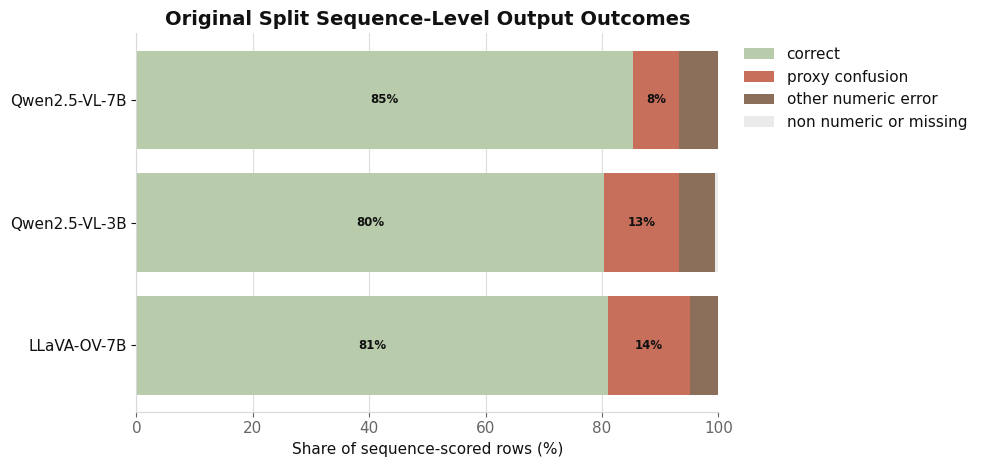

In [16]:
def plot_sequence_outcome_distribution():
    outcome_order = [
        "correct",
        "proxy_confusion",
        "other_numeric_error",
        "non_numeric_or_missing",
    ]

    outcome_colors = {
        "correct": REPORT_COLORS["green"],
        "proxy_confusion": REPORT_COLORS["red"],
        "other_numeric_error": REPORT_COLORS["brown"],
        "non_numeric_or_missing": REPORT_COLORS["grey"],
    }

    counts = (
        sequence_results
        .groupby(["model", "sequence_outcome"])
        .size()
        .reset_index(name="n")
    )

    counts["pct"] = (
        100 * counts["n"] / counts.groupby("model")["n"].transform("sum")
    )

    pivot = (
        counts.pivot(index="model", columns="sequence_outcome", values="pct")
        .reindex(index=SEQUENCE_MODEL_ORDER)
        .reindex(columns=outcome_order)
        .fillna(0)
    )

    fig, ax = plt.subplots(figsize=(10, 4.8), facecolor="white")

    left = np.zeros(len(pivot))

    for outcome in outcome_order:
        vals = pivot[outcome].values

        ax.barh(
            pivot.index,
            vals,
            left=left,
            color=outcome_colors[outcome],
            label=outcome.replace("_", " "),
        )

        for yi, start, val in zip(range(len(pivot)), left, vals):
            if val >= 7:
                ax.text(
                    start + val / 2,
                    yi,
                    f"{val:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8.5,
                    fontweight="bold",
                )

        left += vals

    ax.set_title("Original Split Sequence-Level Output Outcomes")
    ax.set_xlabel("Share of sequence-scored rows (%)")
    ax.set_xlim(0, 100)
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    clean_axes_safe(ax, grid_axis="x")

    plt.tight_layout()
    save_fig_once("original_sequence_outcome_distribution")
    plt.show()


plot_sequence_outcome_distribution()

In [17]:
def load_token_processed_if_needed():
    """
    Use existing signals_eval if present. Otherwise try to load the processed
    token-level signal file created earlier in the notebook.
    """
    if "signals_eval" in globals():
        return signals_eval.copy()

    token_path = BASE / "sanity_checks" / "clean_original_sanity_outputs" / "original_numeric_signals_all_models_processed.csv"

    if token_path.exists():
        return pd.read_csv(token_path)

    print("No processed token signal file found. Skipping token-sequence merge.")
    return None


def prepare_token_for_merge(token_df: pd.DataFrame) -> pd.DataFrame:
    out = token_df.copy()

    if "prefers_gt_token" not in out.columns:
        if "margin_token" in out.columns:
            out["prefers_gt_token"] = pd.to_numeric(out["margin_token"], errors="coerce") > 0
        else:
            out["prefers_gt_token"] = np.nan

    out["margin_token"] = pd.to_numeric(out.get("margin_token", np.nan), errors="coerce")
    out["entropy_token"] = pd.to_numeric(out.get("entropy_token", np.nan), errors="coerce")

    keep = [
        "model", "ID", "margin_token", "entropy_token",
        "prefers_gt_token", "outcome"
    ]

    keep = [c for c in keep if c in out.columns]
    return out[keep].drop_duplicates(subset=["model", "ID"])


def prepare_sequence_for_merge(seq_df: pd.DataFrame) -> pd.DataFrame:
    out = seq_df.copy()

    keep = [
        "model", "ID", "topic", "sub_topic",
        "avg_margin", "pmi_margin",
        "prefers_gt_seq", "prefers_gt_pmi",
        "sequence_outcome", "correct_numeric_eval",
        "generated_matches_proxy",
    ]

    keep = [c for c in keep if c in out.columns]
    return out[keep].drop_duplicates(subset=["model", "ID"])


token_for_merge = load_token_processed_if_needed()

if token_for_merge is not None:
    token_for_merge = prepare_token_for_merge(token_for_merge)
    sequence_for_merge = prepare_sequence_for_merge(sequence_results)

    token_sequence_merged = sequence_for_merge.merge(
        token_for_merge,
        on=["model", "ID"],
        how="inner",
        suffixes=("_seq", "_tok"),
    )

    token_sequence_merged["token_seq_agree"] = (
        token_sequence_merged["prefers_gt_seq"].astype(bool)
        == token_sequence_merged["prefers_gt_token"].astype(bool)
    )

    token_sequence_merged["agreement_type"] = np.select(
        [
            token_sequence_merged["prefers_gt_seq"].eq(True) & token_sequence_merged["prefers_gt_token"].eq(True),
            token_sequence_merged["prefers_gt_seq"].eq(False) & token_sequence_merged["prefers_gt_token"].eq(False),
            token_sequence_merged["prefers_gt_seq"].eq(True) & token_sequence_merged["prefers_gt_token"].eq(False),
            token_sequence_merged["prefers_gt_seq"].eq(False) & token_sequence_merged["prefers_gt_token"].eq(True),
        ],
        [
            "both prefer GT",
            "both prefer proxy",
            "sequence GT / token proxy",
            "sequence proxy / token GT",
        ],
        default="missing",
    )

    merged_path = OUT_DIR / "original_token_sequence_merged_processed.csv"
    token_sequence_merged.to_csv(merged_path, index=False)

    print("Saved token-sequence merged file:")
    print(merged_path)
    print("Merged shape:", token_sequence_merged.shape)

    token_sequence_summary = (
        token_sequence_merged
        .groupby("model", as_index=False)
        .agg(
            n=("ID", "size"),
            agreement_pct=("token_seq_agree", lambda x: 100 * x.mean()),
            both_gt_pct=("agreement_type", lambda x: 100 * (x == "both prefer GT").mean()),
            both_proxy_pct=("agreement_type", lambda x: 100 * (x == "both prefer proxy").mean()),
            seq_gt_token_proxy_pct=("agreement_type", lambda x: 100 * (x == "sequence GT / token proxy").mean()),
            seq_proxy_token_gt_pct=("agreement_type", lambda x: 100 * (x == "sequence proxy / token GT").mean()),
            mean_sequence_margin=("avg_margin", "mean"),
            mean_token_margin=("margin_token", "mean"),
        )
    )

    print("Token-sequence agreement summary:")
    display(token_sequence_summary.round(3))
else:
    token_sequence_merged = None

Saved token-sequence merged file:
C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\outputs_sequence\original_token_sequence_merged_processed.csv
Merged shape: (336, 17)
Token-sequence agreement summary:


,model,n,agreement_pct,both_gt_pct,both_proxy_pct,seq_gt_token_proxy_pct,seq_proxy_token_gt_pct,mean_sequence_margin,mean_token_margin
0,LLaVA-OV-7B,112,99.107,91.071,8.036,0.893,0.000,4.849,5.246
1,Qwen2.5-VL-3B,112,92.857,86.607,6.250,0.893,6.250,3.661,5.758
2,Qwen2.5-VL-7B,112,95.536,88.393,7.143,1.786,2.679,6.357,8.667


Saved: C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\figures\original_token_sequence_agreement.png


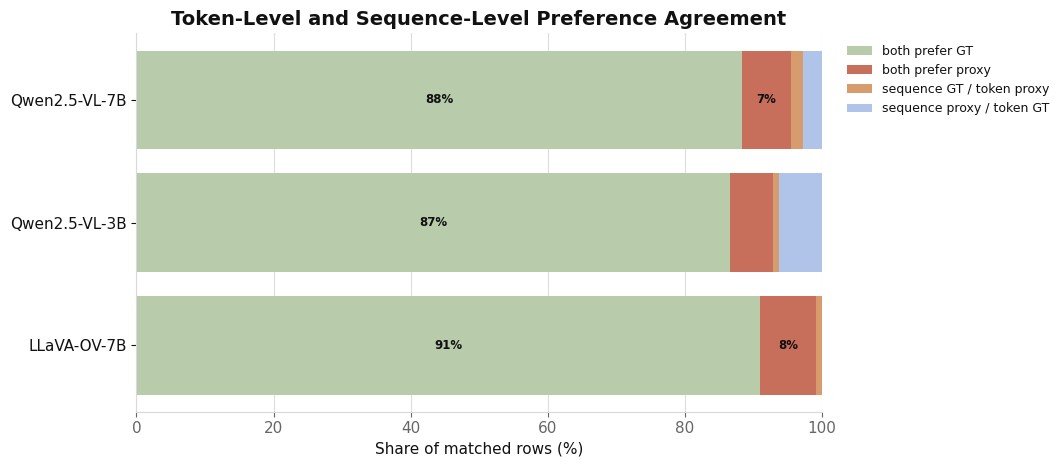

In [18]:
def plot_token_sequence_agreement():
    if token_sequence_merged is None or token_sequence_merged.empty:
        print("Skipping token-sequence agreement plot: no merged data.")
        return

    agreement_order = [
        "both prefer GT",
        "both prefer proxy",
        "sequence GT / token proxy",
        "sequence proxy / token GT",
    ]

    agreement_colors = {
        "both prefer GT": REPORT_COLORS["green"],
        "both prefer proxy": REPORT_COLORS["red"],
        "sequence GT / token proxy": REPORT_COLORS["orange"],
        "sequence proxy / token GT": REPORT_COLORS["blue"],
    }

    counts = (
        token_sequence_merged
        .groupby(["model", "agreement_type"])
        .size()
        .reset_index(name="n")
    )

    counts["pct"] = (
        100 * counts["n"] / counts.groupby("model")["n"].transform("sum")
    )

    pivot = (
        counts.pivot(index="model", columns="agreement_type", values="pct")
        .reindex(index=SEQUENCE_MODEL_ORDER)
        .reindex(columns=agreement_order)
        .fillna(0)
    )

    fig, ax = plt.subplots(figsize=(10.8, 4.8), facecolor="white")

    left = np.zeros(len(pivot))

    for agreement in agreement_order:
        vals = pivot[agreement].values

        ax.barh(
            pivot.index,
            vals,
            left=left,
            color=agreement_colors[agreement],
            label=agreement,
        )

        for yi, start, val in zip(range(len(pivot)), left, vals):
            if val >= 7:
                ax.text(
                    start + val / 2,
                    yi,
                    f"{val:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8.5,
                    fontweight="bold",
                )

        left += vals

    ax.set_title("Token-Level and Sequence-Level Preference Agreement")
    ax.set_xlabel("Share of matched rows (%)")
    ax.set_xlim(0, 100)
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    clean_axes_safe(ax, grid_axis="x")

    plt.tight_layout()
    save_fig_once("original_token_sequence_agreement")
    plt.show()


plot_token_sequence_agreement()

Saved: C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\figures\original_token_vs_sequence_margin.png


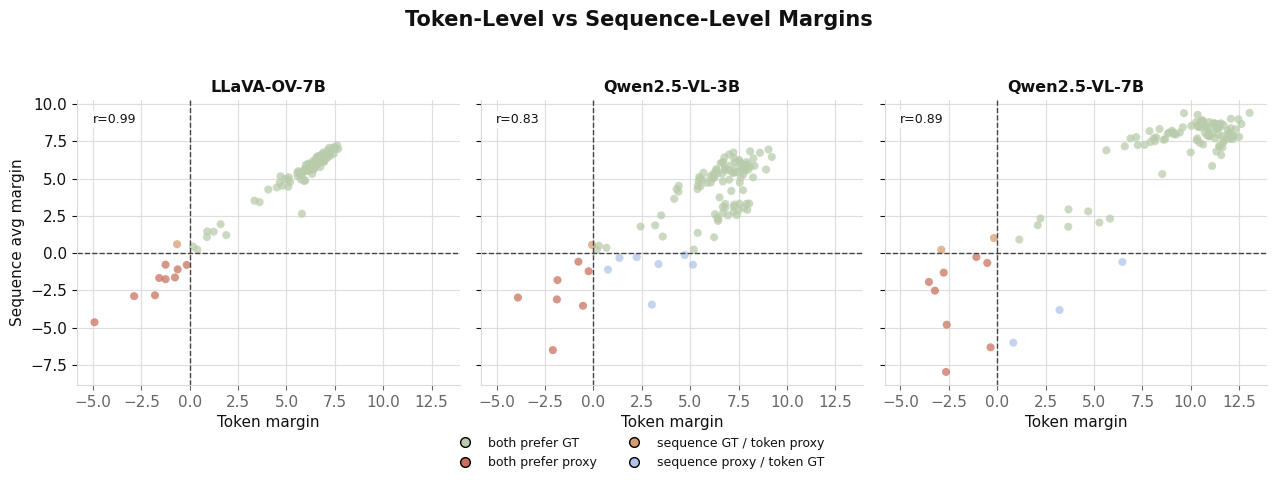

In [19]:
def plot_token_vs_sequence_margin():
    if token_sequence_merged is None or token_sequence_merged.empty:
        print("Skipping token-vs-sequence margin plot: no merged data.")
        return

    df = token_sequence_merged.dropna(subset=["margin_token", "avg_margin"]).copy()

    if df.empty:
        print("Skipping token-vs-sequence margin plot: no rows with both margins.")
        return

    models = [m for m in SEQUENCE_MODEL_ORDER if m in df["model"].unique()]
    fig, axes = plt.subplots(
        1,
        len(models),
        figsize=(4.3 * len(models), 4.2),
        sharex=True,
        sharey=True,
        facecolor="white",
    )

    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        sub = df[df["model"].eq(model)]

        for agreement, color in {
            "both prefer GT": REPORT_COLORS["green"],
            "both prefer proxy": REPORT_COLORS["red"],
            "sequence GT / token proxy": REPORT_COLORS["orange"],
            "sequence proxy / token GT": REPORT_COLORS["blue"],
        }.items():
            tmp = sub[sub["agreement_type"].eq(agreement)]

            if tmp.empty:
                continue

            ax.scatter(
                tmp["margin_token"],
                tmp["avg_margin"],
                s=34,
                alpha=0.72,
                color=color,
                edgecolor="none",
                label=agreement,
            )

        ax.axhline(0, color=REPORT_COLORS["darkgrey"], linestyle="--", linewidth=1.0)
        ax.axvline(0, color=REPORT_COLORS["darkgrey"], linestyle="--", linewidth=1.0)

        if len(sub) >= 3:
            corr = sub[["margin_token", "avg_margin"]].corr().iloc[0, 1]
            ax.text(
                0.04,
                0.92,
                f"r={corr:.2f}",
                transform=ax.transAxes,
                fontsize=9,
                color=REPORT_COLORS["text"],
                bbox=dict(
                    boxstyle="round,pad=0.18",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.9,
                ),
            )

        ax.set_title(model, fontsize=11.5, fontweight="bold")
        ax.set_xlabel("Token margin")
        clean_axes_safe(ax, grid_axis="both")

    axes[0].set_ylabel("Sequence avg margin")

    handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=REPORT_COLORS["green"], markersize=7, label="both prefer GT"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=REPORT_COLORS["red"], markersize=7, label="both prefer proxy"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=REPORT_COLORS["orange"], markersize=7, label="sequence GT / token proxy"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=REPORT_COLORS["blue"], markersize=7, label="sequence proxy / token GT"),
    ]

    fig.legend(
        handles=handles,
        frameon=False,
        loc="lower center",
        ncol=2,
        bbox_to_anchor=(0.5, -0.08),
        fontsize=9,
    )

    fig.suptitle(
        "Token-Level vs Sequence-Level Margins",
        fontsize=15,
        fontweight="bold",
        y=1.04,
    )

    plt.tight_layout()
    save_fig_once("original_token_vs_sequence_margin")
    plt.show()


plot_token_vs_sequence_margin()

In [20]:
paper_sequence_summary = sequence_summary[
    [
        "model",
        "n",
        "prefers_gt_seq_pct",
        "numeric_accuracy_pct",
        "proxy_confusion_pct",
        "mean_avg_margin",
        "median_avg_margin",
        "mean_entropy_step1",
        "pmi_available_pct",
        "pmi_agreement_pct",
        "prefers_gt_pmi_pct",
    ]
].copy()

if token_sequence_merged is not None and not token_sequence_merged.empty:
    paper_token_sequence_summary = (
        token_sequence_merged
        .groupby("model", as_index=False)
        .agg(
            token_sequence_n=("ID", "size"),
            token_sequence_agreement_pct=("token_seq_agree", lambda x: 100 * x.mean()),
            both_prefer_gt_pct=("agreement_type", lambda x: 100 * (x == "both prefer GT").mean()),
            both_prefer_proxy_pct=("agreement_type", lambda x: 100 * (x == "both prefer proxy").mean()),
        )
    )

    paper_sequence_summary = paper_sequence_summary.merge(
        paper_token_sequence_summary,
        on="model",
        how="left",
    )

paper_sequence_summary_path = OUT_DIR / "paper_ready_original_sequence_summary.csv"
paper_sequence_summary.to_csv(paper_sequence_summary_path, index=False)

print("Saved final sequence summary:")
print(paper_sequence_summary_path)

display(paper_sequence_summary.round(3))

print("\nMain sequence files written:")
print(raw_sequence_results_path)
print(raw_sequence_candidates_path)
print(processed_sequence_results_path)

if token_sequence_merged is not None and not token_sequence_merged.empty:
    print(merged_path)

print("\nSequence figures written to:", FIG_DIR)

Saved final sequence summary:
C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\outputs_sequence\paper_ready_original_sequence_summary.csv


,model,n,prefers_gt_seq_pct,numeric_accuracy_pct,proxy_confusion_pct,mean_avg_margin,median_avg_margin,mean_entropy_step1,pmi_available_pct,pmi_agreement_pct,prefers_gt_pmi_pct,token_sequence_n,token_sequence_agreement_pct,both_prefer_gt_pct,both_prefer_proxy_pct
0,LLaVA-OV-7B,163,84.663,80.982,14.110,3.763,5.281,0.521,100.000,94.479,82.209,112,99.107,91.071,8.036
1,Qwen2.5-VL-3B,163,72.393,80.368,12.883,2.376,2.719,0.489,99.387,88.889,79.012,112,92.857,86.607,6.250
2,Qwen2.5-VL-7B,163,90.184,85.276,7.975,5.046,7.188,0.168,100.000,97.546,90.184,112,95.536,88.393,7.143



Main sequence files written:
C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\outputs_sequence\original_sequence_results_all_models_raw_stacked.csv
C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\outputs_sequence\original_sequence_candidates_all_models_raw_stacked.csv
C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\outputs_sequence\original_sequence_results_all_models_processed.csv
C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\outputs_sequence\original_token_sequence_merged_processed.csv

Sequence figures written to: C:\Users\rabia\Documents\Thesis\original_split\sanity_checks\clean_original_sanity_outputs\figures
